# 6장 실습 — 순위가 뒤집힌다

5장에서 하나의 정책에 대해 비트 수를 바꿔 가며 쟀다. 실무의 질문은 그 다음이다 — **여러 압축 후보 중에 무엇을 고를 것인가.**

3권 3장이 이 질문에 답하는 방법을 세웠다. 값은 틀려도 **순위**가 맞으면 후보를 고를 수 있고, 그래서 MMRV가 Pearson r보다 실무에 가깝다는 것이다.

이 노트북은 그 자를 압축 평가에 가져온다. 그리고 문헌이 보고한 불편한 현상을 작은 규모에서 재현한다 — **압축 방법의 순위가 모델마다, 조건마다 뒤집힌다.**

문헌의 예고는 이렇다. W4A4에서 SmoothQuant 가 GR00T-N1.5 에 84.0 인데 π0.5 에 59.3 이고, DuQuant 는 같은 자리에서 70.0 과 94.3 이다. 한쪽에서 14점 이기고 다른 쪽에서 35점 진다. 게다가 같은 방법의 같은 설정을 두 논문이 88.0 과 56.0 으로 적는다.

실행 시간은 CPU에서 7분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MODEL = mujoco.MjModel.from_xml_string(XML)


class Vec:
    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

In [4]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


t0 = time.time()
POLICY = train_rl()
print(f"정책 학습 끝  ({time.time() - t0:.0f}s)")

정책 학습 끝  (64s)


## 정책 둘, 압축 후보 다섯

두 정책을 준비한다. 씨앗만 다른 같은 구조다 — 문헌에서 GR00T 와 π0.5 를 비교한 자리에 해당하고, 여기서는 **같은 과제를 푸는 서로 다른 해**다.

압축 후보는 다섯이다. 5장에서 만든 두 축 — 비트 수와 격자의 단위 — 를 조합한 것에, 흔히 쓰는 완화 기법 하나를 더한다.

- **채널별 4비트 / 텐서별 4비트** — 격자를 출력 채널마다 잡느냐 텐서 전체에 하나로 잡느냐
- **채널별 3비트 / 텐서별 3비트** — 같은 축을 더 공격적인 비트에서
- **클리핑 4비트** — 격자 범위를 최대값이 아니라 분위수로 잡아 이상치를 잘라 낸다

In [5]:
def fq(w, bits, per_channel=True, clip=1.0):
    qmax = 2 ** (bits - 1) - 1
    a = w.abs()
    if per_channel and w.dim() == 2:
        if clip < 1.0:
            r = torch.quantile(a, clip, dim=1, keepdim=True)
        else:
            r = a.amax(dim=1, keepdim=True)
    else:
        if clip < 1.0:
            r = torch.quantile(a.flatten(), clip)
        else:
            r = a.max()
    s = torch.clamp(r / qmax, min=1e-12)
    return torch.clamp(torch.round(w / s), -qmax - 1, qmax) * s


def compress(net, **kw):
    q = copy.deepcopy(net)
    with torch.no_grad():
        for m in q.pi.modules():
            if isinstance(m, nn.Linear):
                m.weight.copy_(fq(m.weight, **kw))
    return q


METHODS = {
    "채널별 4비트": dict(bits=4, per_channel=True),
    "텐서별 4비트": dict(bits=4, per_channel=False),
    "채널별 3비트": dict(bits=3, per_channel=True),
    "텐서별 3비트": dict(bits=3, per_channel=False),
    "클리핑 4비트": dict(bits=4, per_channel=True, clip=.995),
}

t0 = time.time()
POLS = {}
for k, sd in (("정책 A", 0), ("정책 B", 1)):
    POLS[k] = train_rl(seed=sd)
    print(f"{k} 학습 끝  ({time.time() - t0:.0f}s)")

정책 A 학습 끝  (64s)


정책 B 학습 끝  (129s)


## 평가 조건을 둘로 둔다

3권이 반복해서 확인한 것이 있다. **시뮬 안에서 재는 조건 하나로는 부족하다.** 그래서 여기서도 두 조건에서 잰다.

- **명목** — 학습한 것과 같은 조건
- **교란** — 3권 16장의 실기 조건을 줄여 온 것. 관측 편향 6 mm, 제어 지연 1스텝, 마찰 0.8

교란 조건이 실기의 대역이다. 문헌의 실기 결과가 시뮬보다 훨씬 나빴던 자리에 해당한다.

In [6]:
class Pert(Vec):
    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        self._mu = mu
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {
    "명목": dict(),
    "교란": dict(bias=(.006, -.004), lat=1, mu=.80),
}


def score(net, cond, seed=999, n=150, reps=2):
    torch.manual_seed(seed)
    env = Pert(n, seed, **COND[cond])
    sc = []
    for _ in range(EP * reps):
        o = torch.from_numpy(env.obs())
        with torch.no_grad():
            a = net.dist(o).sample().numpy()
        sc += env.step(a)[2]
    return float(np.mean(sc))

In [7]:
t0 = time.time()
TAB = {}
for pk, net in POLS.items():
    for ck in COND:
        row = {"원본": score(net, ck)}
        for mk, kw in METHODS.items():
            row[mk] = score(compress(net, **kw), ck)
        TAB[(pk, ck)] = row
    print(f"{pk} 평가 끝  ({time.time() - t0:.0f}s)")

KEYS = ["원본"] + list(METHODS)
print()
print(pad("압축 방법", 16)
      + "".join(pad(f"{p} {c}", 13, True)
               for p in POLS for c in COND))
for mk in KEYS:
    print(pad(mk, 16)
          + "".join(pad(f"{TAB[(p, c)][mk]:.2f}", 13, True)
                   for p in POLS for c in COND))

정책 A 평가 끝  (53s)


정책 B 평가 끝  (106s)

압축 방법         정책 A 명목  정책 A 교란  정책 B 명목  정책 B 교란
원본                     0.92         0.73         0.94         0.46
채널별 4비트             0.95         0.85         0.98         0.58
텐서별 4비트             0.97         0.76         0.90         0.38
채널별 3비트             0.93         0.24         0.92         0.31
텐서별 3비트             0.48         0.06         0.86         0.21
클리핑 4비트             0.90         0.80         0.98         0.49


## 순위를 뽑아 본다

값 대신 순위로 다시 적는다. 압축 후보 다섯만 놓고 1등부터 5등까지다.

In [8]:
def ranks(row):
    ks = list(METHODS)
    order = sorted(ks, key=lambda k: -row[k])
    return {k: order.index(k) + 1 for k in ks}


R = {col: ranks(TAB[col]) for col in TAB}
print(pad("압축 방법", 16)
      + "".join(pad(f"{p} {c}", 13, True)
               for p in POLS for c in COND))
for mk in METHODS:
    print(pad(mk, 16)
          + "".join(pad(f"{R[(p, c)][mk]}위", 13, True)
                   for p in POLS for c in COND))

압축 방법         정책 A 명목  정책 A 교란  정책 B 명목  정책 B 교란
채널별 4비트              2위          1위          1위          1위
텐서별 4비트              1위          3위          4위          3위
채널별 3비트              3위          4위          3위          4위
텐서별 3비트              5위          5위          5위          5위
클리핑 4비트              4위          2위          2위          2위


In [9]:
cols = [(p, c) for p in POLS for c in COND]
print(pad("비교", 30) + pad("순위 뒤집힘", 14, True)
      + pad("MMRV", 10, True))
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        a, b = cols[i], cols[j]
        ks = list(METHODS)
        flip, mm = 0, []
        for x in range(len(ks)):
            worst = 0.
            for y in range(len(ks)):
                if x == y:
                    continue
                da = TAB[a][ks[x]] - TAB[a][ks[y]]
                db = TAB[b][ks[x]] - TAB[b][ks[y]]
                if np.sign(da) != np.sign(db):
                    flip += 1
                    worst = max(worst, abs(db))
            mm.append(worst)
        lab = f"{a[0]} {a[1]} vs {b[0]} {b[1]}"
        print(pad(lab, 30) + pad(f"{flip // 2}쌍", 14, True)
              + pad(f"{np.mean(mm):.3f}", 10, True))

비교                             순위 뒤집힘      MMRV
정책 A 명목 vs 정책 A 교란               3쌍     0.260
정책 A 명목 vs 정책 B 명목               5쌍     0.057
정책 A 명목 vs 정책 B 교란               3쌍     0.148
정책 A 교란 vs 정책 B 명목               2쌍     0.008
정책 A 교란 vs 정책 B 교란               0쌍     0.000
정책 B 명목 vs 정책 B 교란               2쌍     0.065


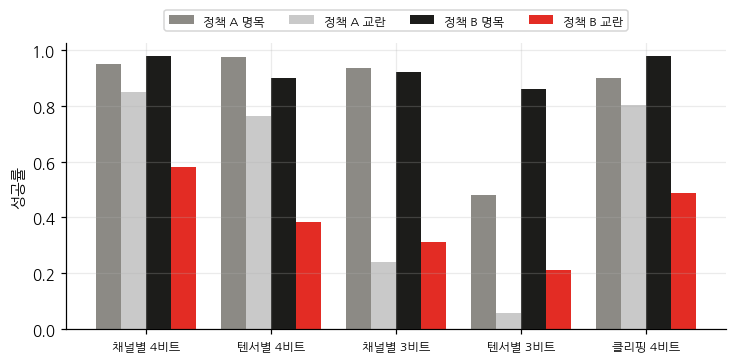

In [10]:
fig, ax = plt.subplots(figsize=(6.8, 3.4))
ks = list(METHODS)
x = np.arange(len(ks))
w = .2
for i, (p, c) in enumerate(cols):
    v = [TAB[(p, c)][k] for k in ks]
    ax.bar(x + (i - 1.5) * w, v, w,
           color=[GREY, "#C9C9C9", INK, RED][i], label=f"{p} {c}")
ax.set_xticks(x)
ax.set_xticklabels(ks, fontsize=8)
ax.set_ylabel("성공률")
ax.legend(fontsize=8, ncol=4, loc="lower center",
          bbox_to_anchor=(.5, 1.02))
plt.tight_layout()
plt.show()

## 그래서 어떻게 고르는가

표가 말하는 것은 「어느 방법이 좋다」가 아니다. **고르는 절차**다.

3권 16장이 같은 자리에 왔었다. 축별로 따로 잰 점수로 합친 조건을 맞히려 했다가 실패했고, 결론은 **합친 조건 하나에서 순위로 고른다**였다. 여기서도 같다.

- **자기 모델에서 잰다.** 남의 표의 1등이 내 모델의 1등이 아니다
- **배포 조건에서 잰다.** 명목 조건의 순위가 교란 조건의 순위와 다르면, 배포되는 것은 교란 쪽이다
- **닫힌 고리에서 잰다.** 5장에서 본 대로 정적 오차는 이것을 예측하지 못한다

In [11]:
print(pad("고르는 기준", 20) + pad("고른 방법", 16, True)
      + pad("교란 성공률", 14, True))
tgt = ("정책 A", "교란")
for lab, col in (("명목 조건에서 1등", ("정책 A", "명목")),
                 ("다른 정책에서 1등", ("정책 B", "교란")),
                 ("배포 조건에서 1등", tgt)):
    best = max(METHODS, key=lambda k: TAB[col][k])
    print(pad(lab, 20) + pad(best, 16, True)
          + pad(f"{TAB[tgt][best]:.2f}", 14, True))

고르는 기준                고른 방법   교란 성공률
명목 조건에서 1등       텐서별 4비트          0.76
다른 정책에서 1등       채널별 4비트          0.85
배포 조건에서 1등       채널별 4비트          0.85


## 정리

**압축 방법의 순위는 모델을 옮기면 바뀐다.** 같은 과제를 푸는 두 정책 사이에서도 바뀐다. 문헌이 서로 다른 VLA 에서 본 것과 같은 구조다.

**평가 조건을 옮겨도 바뀐다.** 명목 조건에서 1등인 방법이 교란 조건에서 1등이 아니다. 그리고 배포되는 것은 교란 쪽이다.

**그래서 남의 표를 옮겨 쓸 수 없다.** 3권이 열여덟 장 동안 말한 것이 압축에서도 그대로 성립한다 — 자기 모델, 자기 조건, 닫힌 고리에서 다시 재야 한다.

**MMRV 는 여기서도 쓸 수 있다.** 값이 아니라 순위의 보존을 재는 자이고, 압축 후보를 고르는 일은 정확히 순위의 문제다.

다음 장은 양자화 말고 다른 길들을 같은 표로 잰다.